In [1]:
import shap
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/train_final.csv')
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

print("Data loaded!")

c:\Users\Dell\Desktop\mlproject\house_price_prediction\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded!


In [2]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

print("Model retrained!")

Model retrained!


In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed!")

SHAP values computed!


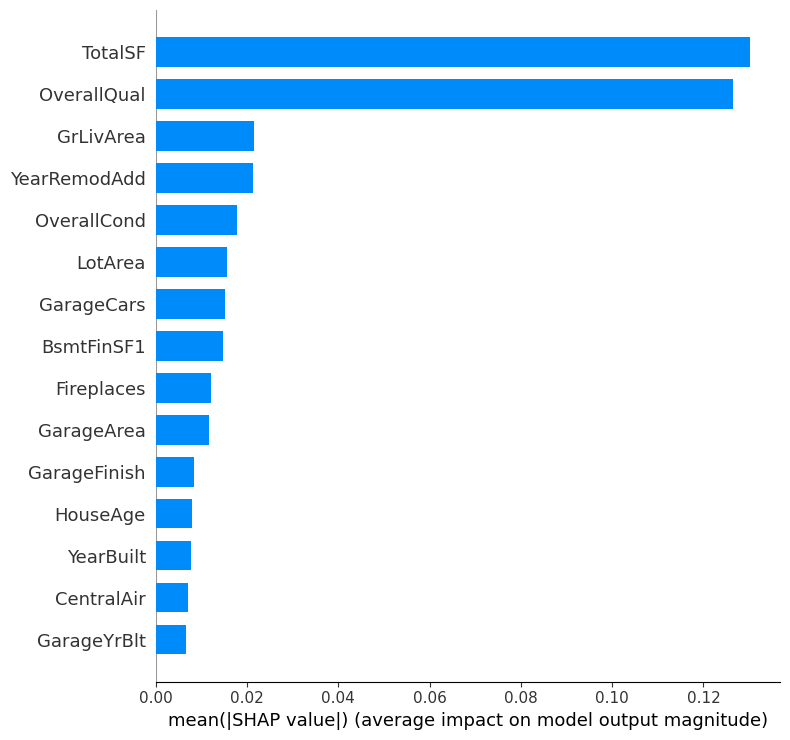

In [4]:
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15)
plt.show()

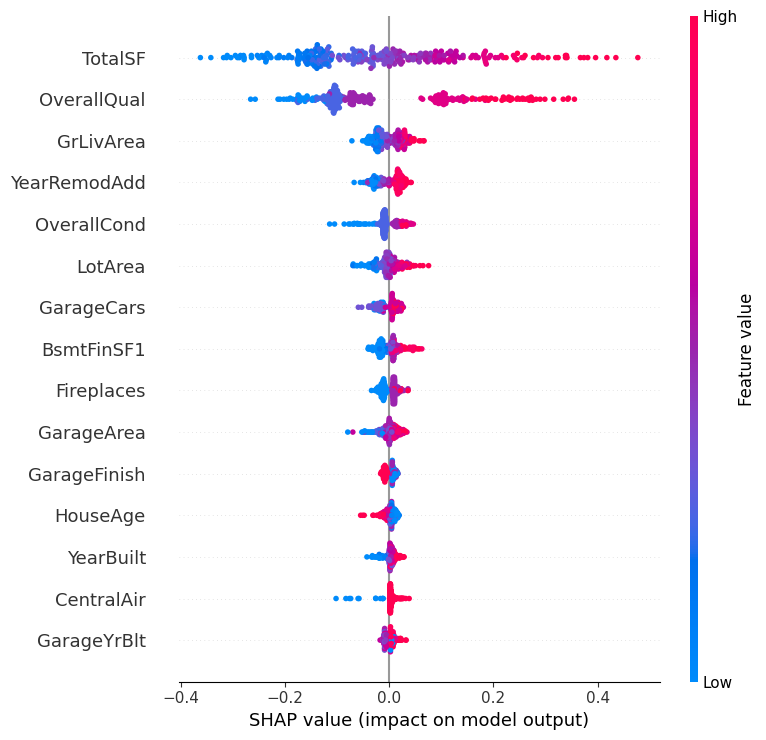

In [5]:
shap.summary_plot(shap_values, X_test, max_display=15)
plt.show()

In [6]:
feature_shap = pd.Series(shap_values[0], index=X_test.columns)

print("Top 5 features pushing price UP:")
print(feature_shap.sort_values(ascending=False).head())

print("\nTop 5 features pushing price DOWN:")
print(feature_shap.sort_values(ascending=True).head())

Top 5 features pushing price UP:
OverallCond     0.025934
YearRemodAdd    0.017303
GarageFinish    0.013069
BsmtFinSF1      0.007317
YearBuilt       0.004628
dtype: float32

Top 5 features pushing price DOWN:
OverallQual   -0.069337
TotalSF       -0.068753
GarageCars    -0.034299
GrLivArea     -0.023032
GarageArea    -0.010869
dtype: float32
